Step 1 — Import Libraries

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Step 2 — Load Dataset

In [61]:
df = pd.read_csv("Superstore.csv", encoding='ISO-8859-1')

Step 3 

In [62]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

Step 3 — Keep Required Columns

In [64]:
df = df[
    [
        'Order Date',
        'Ship Date',
        'Ship Mode',
        'Segment',
        'Country',
        'City',
        'State',
        'Region',
        'Category',
        'Sub-Category',
        'Product Name',
        'Sales',
        'Quantity',
        'Discount',
        'Profit'
    ]
]

Step 4 — Check Missing Values

In [65]:
print(df.isnull().sum())

Order Date      0
Ship Date       0
Ship Mode       0
Segment         0
Country         0
City            0
State           0
Region          0
Category        0
Sub-Category    0
Product Name    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64


Outlier Detection and Removing

In [66]:
# Select numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Columns:")
print(numerical_columns)

for col in numerical_columns:

    # Calculate Q1 and Q3
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Calculate IQR
    IQR = Q3 - Q1

    # Define limits
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Find outliers
    outliers = df[
        (df[col] < lower_limit) |
        (df[col] > upper_limit)
    ]

    print(f"\nColumn: {col}")
    print(f"Number of Outliers: {outliers.shape[0]}")

Numerical Columns:
Index(['Sales', 'Quantity', 'Discount', 'Profit'], dtype='object')

Column: Sales
Number of Outliers: 1167

Column: Quantity
Number of Outliers: 170

Column: Discount
Number of Outliers: 856

Column: Profit
Number of Outliers: 1881


In [67]:
for col in numerical_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower_limit) &
        (df[col] <= upper_limit)
    ]

Step 5 — Check Duplicates

In [68]:
print(df.duplicated().sum())

1


In [69]:
df.drop_duplicates(inplace=True)

Step 6 — Convert Dates

In [70]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [71]:
#Create new columns
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month_name()

Step 7 — Basic Analysis

In [72]:
#Total Sales
print("Total Sales:", df['Sales'].sum())

Total Sales: 459697.0187


In [73]:
#Total Profit
print("Total Profit:", df['Profit'].sum())

Total Profit: 78946.9993


In [74]:
#Best Category
print(df.groupby('Category')['Sales'].sum().sort_values(ascending=False))

Category
Office Supplies    197919.7310
Furniture          139013.8597
Technology         122763.4280
Name: Sales, dtype: float64


Step 8 — Visualization

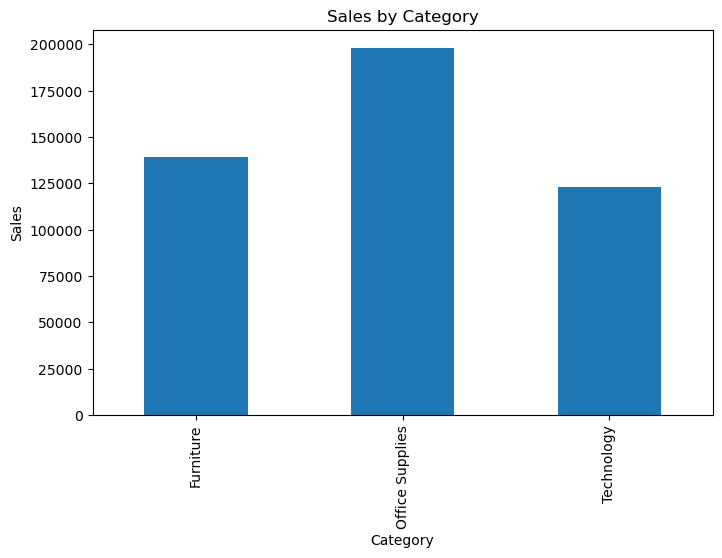

In [75]:
#1. Sales by Category
plt.figure(figsize=(8,5))

df.groupby('Category')['Sales'].sum().plot(kind='bar')

plt.title('Sales by Category')
plt.ylabel('Sales')
plt.show()  

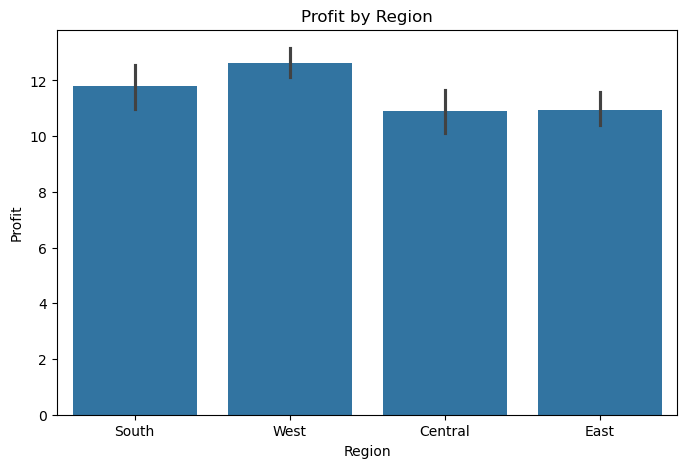

In [76]:
#2. Profit by Region
plt.figure(figsize=(8,5))
sns.barplot(x='Region', y='Profit', data=df)
plt.title('Profit by Region')
plt.show()

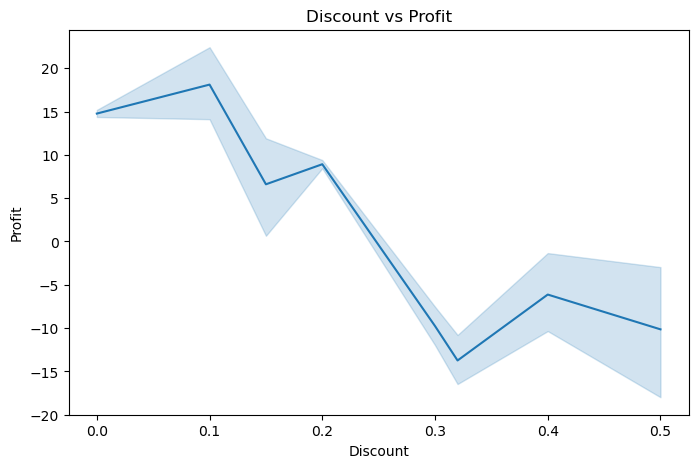

In [77]:
#3. Discount vs Profit
plt.figure(figsize=(8,5))

sns.lineplot(x='Discount', y='Profit', data=df)

plt.title('Discount vs Profit')

plt.show()



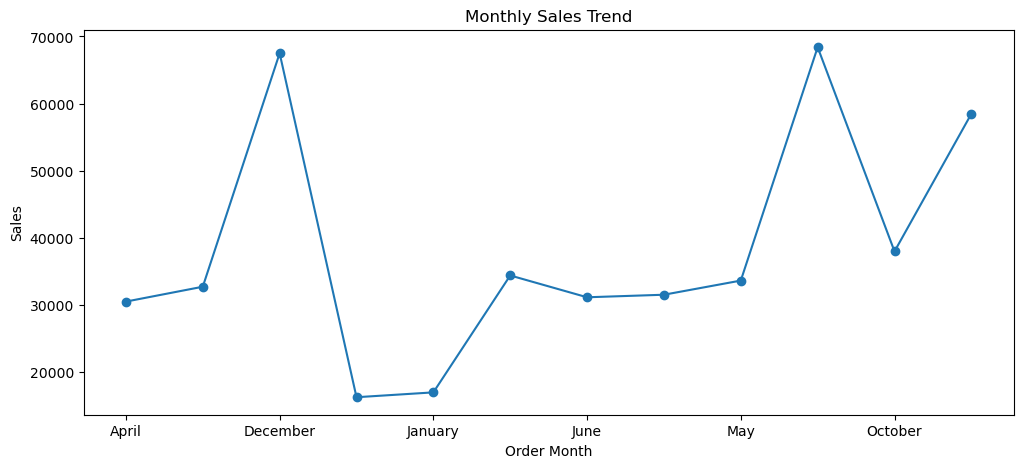

In [78]:
#4. Monthly Sales Trend

monthly_sales = df.groupby('Order Month')['Sales'].sum()

plt.figure(figsize=(12,5))

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')

plt.ylabel('Sales')

plt.show()

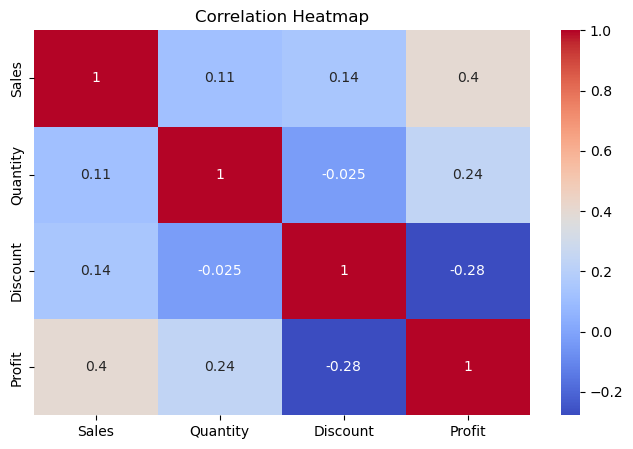

In [79]:
#5. Correlation Heatmap

plt.figure(figsize=(8,5))

sns.heatmap(
    df[['Sales', 'Quantity', 'Discount', 'Profit']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

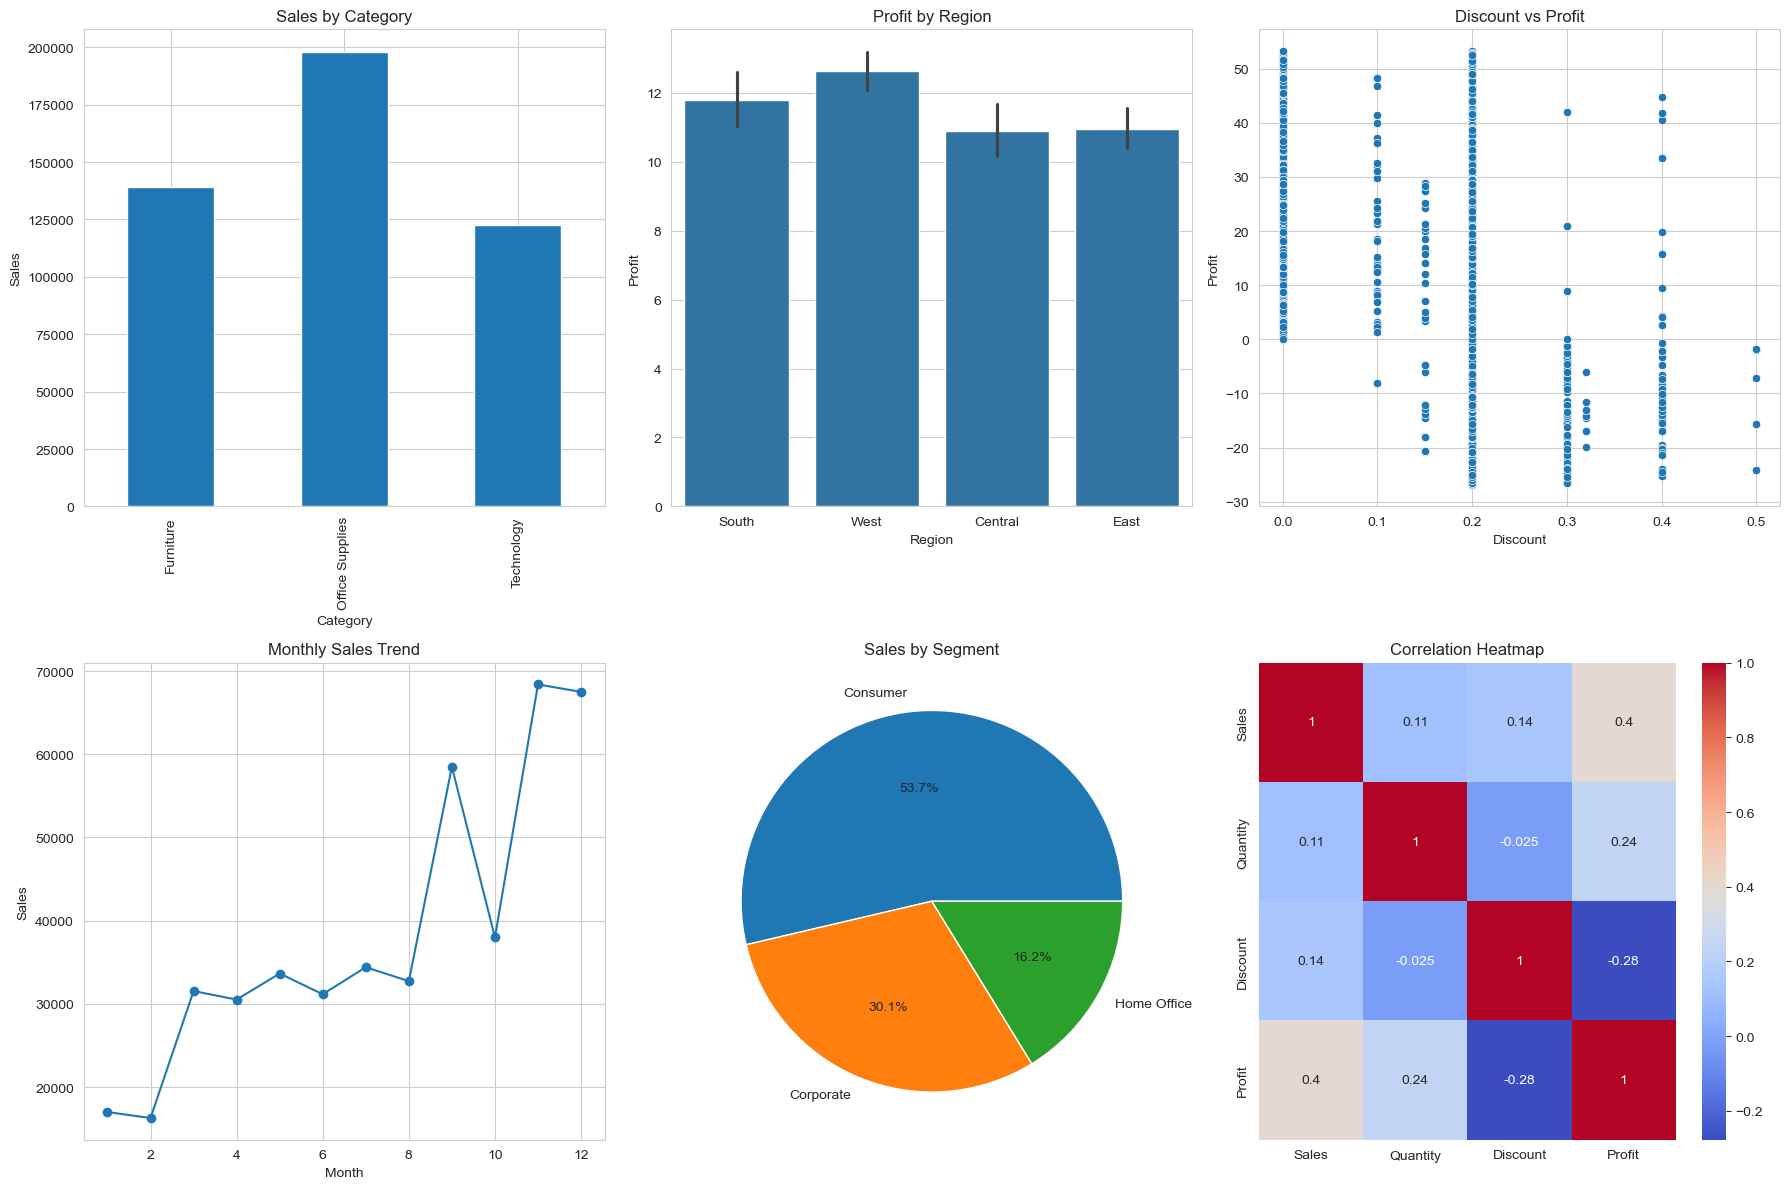

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dashboard Style
sns.set_style("whitegrid")

# Create Figure
fig = plt.figure(figsize=(18,12))

# -------------------------------
# 1. Sales by Category
# -------------------------------
plt.subplot(2,3,1)

df.groupby('Category')['Sales'].sum().plot(
    kind='bar'
)

plt.title("Sales by Category")
plt.ylabel("Sales")

# -------------------------------
# 2. Profit by Region
# -------------------------------
plt.subplot(2,3,2)

sns.barplot(
    x='Region',
    y='Profit',
    data=df
)

plt.title("Profit by Region")

# -------------------------------
# 3. Discount vs Profit
# -------------------------------
plt.subplot(2,3,3)

sns.scatterplot(
    x='Discount',
    y='Profit',
    data=df
)

plt.title("Discount vs Profit")

# -------------------------------
# 4. Monthly Sales Trend
# -------------------------------
plt.subplot(2,3,4)

monthly_sales = df.groupby(
    df['Order Date'].dt.month
)['Sales'].sum()

monthly_sales.plot(
    kind='line',
    marker='o'
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

# -------------------------------
# 5. Segment Wise Sales
# -------------------------------
plt.subplot(2,3,5)

df.groupby('Segment')['Sales'].sum().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Sales by Segment")
plt.ylabel("")

# -------------------------------
# 6. Correlation Heatmap
# -------------------------------
plt.subplot(2,3,6)

sns.heatmap(
    df[['Sales','Quantity','Discount','Profit']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

# Layout
plt.tight_layout()

# Show Dashboard
plt.show()